# This notebook explores transfer learning for the small dataset we have

Plan: use 1D-Resnet + mask channels

for the raw 1D CTG signals, a small 1D-ResNet is one of the best choice for the dataset size. 1D-ResNet works well on time-series.

Evaluate: two different input appraches

1- Same as CTG-Net pre-processing: 
- Records were excluded if they were shorter than 30 mins and contained more than 16% signal loss. 

- Takes fetal heart rate and uterine contraction signals of 1800 time points (downsampled at 1 hz for 30 min) as input

2- Cleaned Input regarding to daydulo et. al. technique

- Locate the pre-processed/cleaned FHR singals. 

- Pre-process UC signals. 

Note that: this notebook explores second approach: using cleaned input. 

#

### **Set Up- Import packages and set up environment for reproducible results**

In [10]:
# Necessary imports
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

### **Locate to Pre-processed/Cleaned FHR Signals**

Note: please locate to src/notebooks/04_signal_transformation.ipynb for the details for pre-processing steps and more information.

In [2]:
# Path to cleaned FHR CSV files
CLEAN_FHR_PATH = Path("cleaned_data/clean_csv")

Loaded 552 cleaned FHR records


In [4]:
# Function to load a single cleaned FHR record
def load_clean_fhr(record_id):
    """
    Load cleaned FHR signal from CSV file.
    
    Args:
        record_id: Record ID (e.g., '1001')
    
    Returns:
        pandas DataFrame or numpy array with FHR signal
    """
    csv_path = CLEAN_FHR_PATH / f"{record_id}.csv"
    if not csv_path.exists():
        print(f"Warning: {csv_path} not found")
        return None
    return pd.read_csv(csv_path)


In [5]:
# Load all available cleaned FHR files
def load_all_clean_fhr():
    """
    Load all cleaned FHR signals from the clean_csv directory.
    
    Returns:
        Dictionary with record_id as key and DataFrame as value
    """
    csv_files = {}
    for csv_file in CLEAN_FHR_PATH.glob("*.csv"):
        record_id = csv_file.stem  # Get filename without extension
        csv_files[record_id] = pd.read_csv(csv_file)
    print(f"Loaded {len(csv_files)} cleaned FHR records")
    return csv_files

# Load all cleaned FHR data
cleaned_fhr = load_all_clean_fhr()

Loaded 552 cleaned FHR records


In [3]:
# Example: Access a specific record
chosen_record = cleaned_fhr['1001']
chosen_record.head()

,FHR
0,150.50
1,150.50
2,151.00
3,151.25
4,151.25


## Visualization: Raw vs Pre-processed FHR for Record 1001

In [ ]:
# Load raw FHR data from .dat file
record_id = "1001"
# Construct absolute path from workspace
workspace_root = r"c:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation"
raw_data_path = os.path.join(workspace_root, "src", "data", "raw_dataset", "1001")
csv_path = os.path.join(workspace_root, "src", "cleaned_data", "clean_csv", "1001.csv")
lineplot_path = os.path.join(workspace_root, "src", "cleaned_data", "lineplots", "1001.png")

print(f"Loading raw data from: {raw_data_path}")
print(f"Loading CSV data from: {csv_path}")

# Read the WFDB record (includes .hea and .dat files)
record = wfdb.rdrecord(raw_data_path)
fs = record.fs  # Sampling frequency

# Extract FHR (first channel) and UC (second channel)
fhr_raw = record.p_signal[:, 0]  # Raw FHR signal
uc_raw = record.p_signal[:, 1]   # Uterine contractions

print(f"Raw FHR Signal - Sampling Frequency: {fs} Hz, Length: {len(fhr_raw)} samples")
print(f"Raw FHR range: {fhr_raw.min():.2f} - {fhr_raw.max():.2f} bpm")

# Load pre-processed FHR data from CSV
cleaned_fhr = pd.read_csv(csv_path)
fhr_processed = cleaned_fhr["FHR"].values

print(f"\nProcessed FHR Signal - Length: {len(fhr_processed)} samples (at 1 Hz)")
print(f"Processed FHR range: {fhr_processed.min():.2f} - {fhr_processed.max():.2f} bpm")

Loading raw data from: c:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src\data\raw_dataset\1001
Loading CSV data from: c:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src\cleaned_data\clean_csv\1001.csv
Raw FHR Signal - Sampling Frequency: 4 Hz, Length: 19200 samples
Raw FHR range: 0.00 - 193.00 bpm

Processed FHR Signal - Length: 16324 samples (at 1 Hz)
Processed FHR range: 51.75 - 193.00 bpm


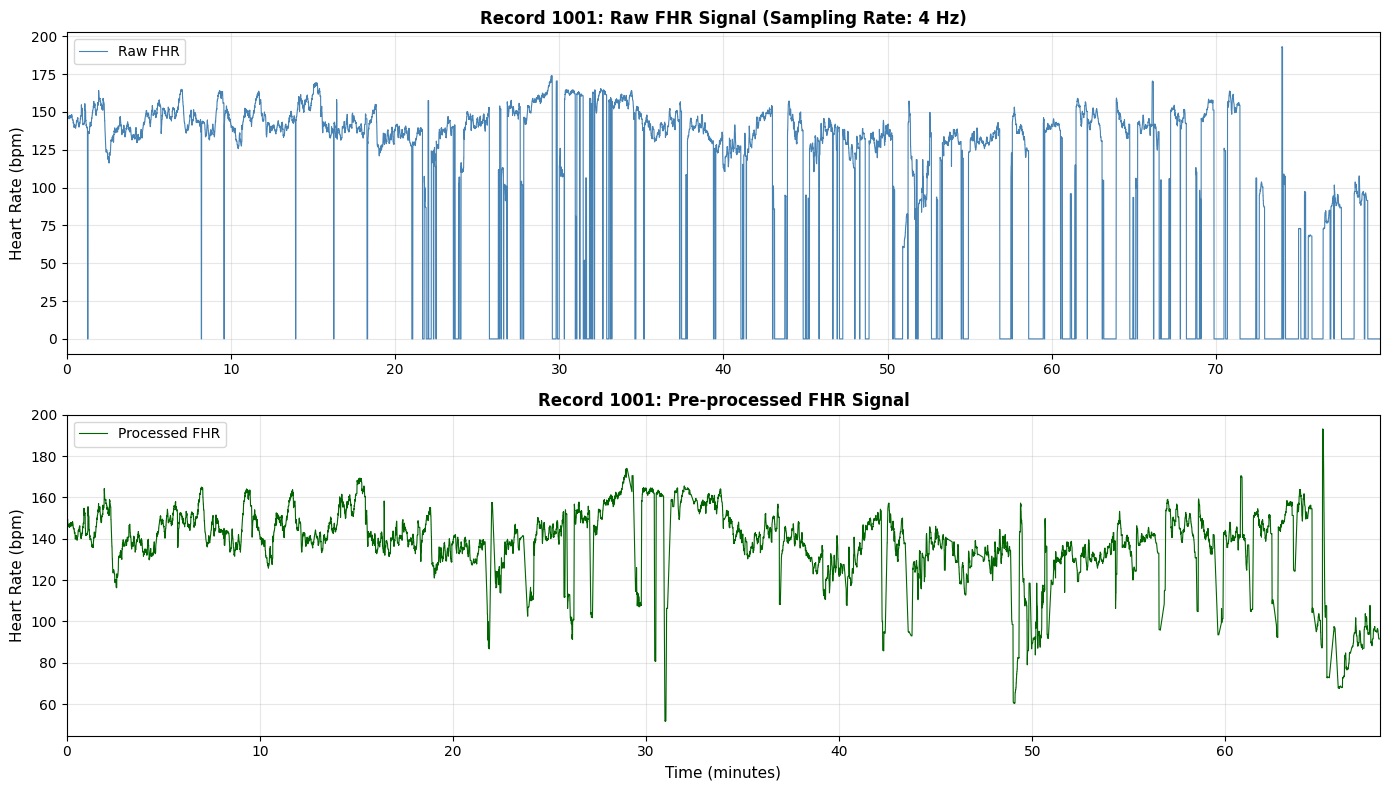


Visualization complete!
Raw signal duration: 80.00 minutes
Processed signal duration: 272.07 minutes


In [16]:
# Create comparison visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Time axes
time_raw = np.arange(len(fhr_raw)) / fs  # Convert to seconds, then to minutes
time_processed = np.arange(len(fhr_processed)) / 4  # Accounting for 4 Hz

# Plot 1: Raw FHR
axes[0].plot(time_raw / 60, fhr_raw, label='Raw FHR', color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Heart Rate (bpm)', fontsize=11)
axes[0].set_title(f'Record {record_id}: Raw FHR Signal (Sampling Rate: {fs} Hz)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_xlim([time_raw.min() / 60, time_raw.max() / 60])

# Plot 2: Processed FHR
axes[1].plot(time_processed / 60, fhr_processed, label='Processed FHR', color='darkgreen', linewidth=0.8)
axes[1].set_xlabel('Time (minutes)', fontsize=11)
axes[1].set_ylabel('Heart Rate (bpm)', fontsize=11)
axes[1].set_title(f'Record {record_id}: Pre-processed FHR Signal', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xlim([time_processed.min() / 60, time_processed.max() / 60])

plt.tight_layout()
plt.show()

print(f"\nVisualization complete!")
print(f"Raw signal duration: {len(fhr_raw) / fs / 60:.2f} minutes")
print(f"Processed signal duration: {len(fhr_processed) / 60:.2f} minutes")

In [ ]:
# raw UC
